# WASTE CLASSIFICATION — COMPLETE COLAB MANUAL
## 05 — Ifaza M.D.U — IT25102486
### Pixel Normalization

**IMPORTANT:** This version is intentionally code-heavy. Each numbered cell below is intended to be copied into Google Colab and run in sequence. Do not skip validation cells.

## A. ONE-TIME COLAB SETUP
### 00. Set member identity — run this before the common cells

In [ ]:
MEMBER_NAME = "Ifaza M.D.U"
IT_NUMBER = "IT25102486"
TASK = "Pixel Normalization"
print(MEMBER_NAME, IT_NUMBER, TASK)

Ifaza M.D.U IT25102486 Pixel Normalization


### 01. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount("/content/drive")
print("Google Drive mounted successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully.


### 02. Install/check packages

In [ ]:
!pip -q install pandas pillow matplotlib numpy imagehash
import os, shutil, hashlib, json, csv, math
from pathlib import Path
import pandas as pd
import numpy as np
from PIL import Image, ImageFile
import matplotlib.pyplot as plt

ImageFile.LOAD_TRUNCATED_IMAGES = False
print("Packages imported.")

Packages imported.


### 03. Define project folders

In [ ]:
PROJECT = Path("/content/drive/MyDrive/Waste_Classification")
RAW_DIR = PROJECT / "data" / "raw"
PROCESSED_DIR = PROJECT / "data" / "processed"
RESULTS_DIR = PROJECT / "results"
REPORT_DIR = PROJECT / "audit_reports"
EDA_DIR = RESULTS_DIR / "eda_visualizations"
OUTPUT_DIR = RESULTS_DIR / "outputs"

for p in [PROCESSED_DIR, RESULTS_DIR, REPORT_DIR, EDA_DIR, OUTPUT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

IMAGE_EXTS = {".jpg",".jpeg",".png",".webp",".bmp",".gif",".tif",".tiff"}
print("PROJECT =", PROJECT)
print("RAW_DIR =", RAW_DIR)
assert PROJECT.exists(), "Waste_Classification folder was not found."
assert RAW_DIR.exists(), "data/raw was not found. Check your Drive folder."

PROJECT = /content/drive/MyDrive/Waste_Classification
RAW_DIR = /content/drive/MyDrive/Waste_Classification/data/raw


### 04. List project folders

In [ ]:
for p in [PROJECT, RAW_DIR, PROCESSED_DIR, RESULTS_DIR, REPORT_DIR]:
    print("\n", p)
    if p.exists():
        for child in list(p.iterdir())[:20]:
            print("  ", child.name)


 /content/drive/MyDrive/Waste_Classification
   data
   results
   audit_reports
   notebooks
   code
   README.md
   .gitignore
   .git_backup
   .git

 /content/drive/MyDrive/Waste_Classification/data/raw
   Hazardous
   Non-Recyclable
   Organic
   Recyclable
   .complete

 /content/drive/MyDrive/Waste_Classification/data/processed
   stage1_cleaning
   stage2_deduplicated
   stage2_visual_deduplicated
   stage3_labels
   stage4_standardized
   stage5_normalized

 /content/drive/MyDrive/Waste_Classification/results
   eda_visualizations
   outputs
   member2_visual_review (2)
   member2_visual_review (1)
   member2_visual_review
   member2_visual_review_final
   logs

 /content/drive/MyDrive/Waste_Classification/audit_reports
   member1_image_audit.csv
   member1_image_warnings.csv
   member3_label_warnings.csv
   member4_standardization_manifest.csv


### 05. Create a run log

In [ ]:
RUN_LOG = OUTPUT_DIR / "preprocessing_run_log.txt"
RUN_LOG.write_text(
    "Waste Classification preprocessing run\n"
    f"Member: {MEMBER_NAME}\n"
    f"IT Number: {IT_NUMBER}\n"
)
print("Run log:", RUN_LOG)

Run log: /content/drive/MyDrive/Waste_Classification/results/outputs/preprocessing_run_log.txt


## B. YOUR COMPLETE ASSIGNED-PREPROCESSING CODE
### 06. Set input stage

In [ ]:
STAGE4 = PROCESSED_DIR / "stage4_standardized"
assert STAGE4.exists(), "Stage 4 is missing."
files = sorted(STAGE4.rglob("*.jpg"))
print("Input images:", len(files))

Input images: 2136


### 07. Install/import PyTorch

In [ ]:
import torch
from torchvision import transforms
print("PyTorch:", torch.__version__)

PyTorch: 2.11.0+cpu


### 08. Define ImageNet normalization

In [ ]:
IMAGE_SIZE = (224,224)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

to_tensor = transforms.ToTensor()
normalize = transforms.Normalize(
    mean=IMAGENET_MEAN,
    std=IMAGENET_STD
)
print("Mean:", IMAGENET_MEAN)
print("Std :", IMAGENET_STD)

Mean: [0.485, 0.456, 0.406]
Std : [0.229, 0.224, 0.225]


### 09. Test one image before/after normalization

In [ ]:
img=Image.open(files[0]).convert("RGB")
tensor_before=to_tensor(img)
tensor_after=normalize(tensor_before.clone())

print("Image:",files[0].name)
print("Before min/max/mean:",float(tensor_before.min()),float(tensor_before.max()),float(tensor_before.mean()))
print("After min/max/mean:",float(tensor_after.min()),float(tensor_after.max()),float(tensor_after.mean()))
print("Tensor shape:",tensor_after.shape)

Image: 1-s2.0-S0892687521004477-ga1.jpg
Before min/max/mean: 0.0 1.0 0.9037959575653076
After min/max/mean: -2.1179039478302 2.640000104904175 2.0136125087738037
Tensor shape: torch.Size([3, 224, 224])


### 10. Plot normalization EDA

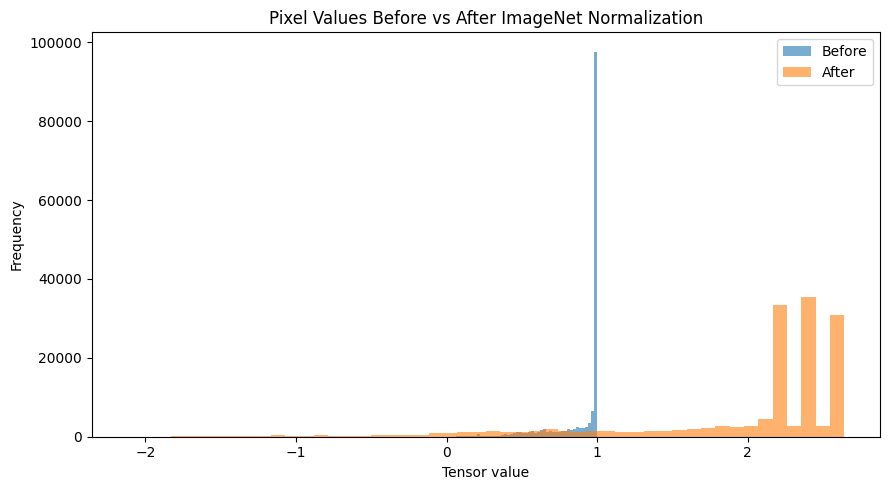

Saved: /content/drive/MyDrive/Waste_Classification/results/eda_visualizations/member5_normalization_histogram.png


In [ ]:
plt.figure(figsize=(9,5))
plt.hist(tensor_before.flatten().numpy(),bins=50,alpha=.6,label="Before")
plt.hist(tensor_after.flatten().numpy(),bins=50,alpha=.6,label="After")
plt.title("Pixel Values Before vs After ImageNet Normalization")
plt.xlabel("Tensor value")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
path=EDA_DIR/"member5_normalization_histogram.png"
plt.savefig(path,dpi=200); plt.show()
print("Saved:",path)

### 11. Verify transform on a batch

In [ ]:
sample_files=files[:min(16,len(files))]
batch=torch.stack([normalize(to_tensor(Image.open(p).convert("RGB"))) for p in sample_files])
print("Batch shape:",batch.shape)
print("Batch mean:",float(batch.mean()))
print("Batch std:",float(batch.std()))
assert batch.shape[1:] == (3,224,224)

Batch shape: torch.Size([16, 3, 224, 224])
Batch mean: 0.8236435055732727
Batch std: 1.4713338613510132


### 12. Save exact preprocessing specification

In [ ]:
spec = {
    "resize": [224,224],
    "to_tensor": True,
    "normalize_mean": IMAGENET_MEAN,
    "normalize_std": IMAGENET_STD,
    "note": "Normalization is a model-input transform; do not save normalized values as JPEG."
}
path=OUTPUT_DIR/"member5_normalization_spec.json"
path.write_text(json.dumps(spec,indent=2))
print("Saved:",path)

Saved: /content/drive/MyDrive/Waste_Classification/results/outputs/member5_normalization_spec.json


### 13. Create reusable transform code file

In [ ]:
transform_code = """from torchvision import transforms

train_or_eval_normalize = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])
"""
path=OUTPUT_DIR/"member5_normalization_transform.py"
path.write_text(transform_code)
print("Saved:",path)

Saved: /content/drive/MyDrive/Waste_Classification/results/outputs/member5_normalization_transform.py


### 14. Git save commands

In [ ]:
!git -C /content/drive/MyDrive/Waste_Classification status
!git -C /content/drive/MyDrive/Waste_Classification add notebooks results/outputs results/eda_visualizations
!git -C /content/drive/MyDrive/Waste_Classification commit -m "IT25102486 - normalization transform"
# !git -C /content/drive/MyDrive/Waste_Classification push

On branch main

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.git_backup/
	.gitignore
	README.md
	audit_reports/
	notebooks/
	results/

nothing added to commit but untracked files present (use "git add" to track)
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@a560bd05fa65.(none)')


## C. FINAL CHECKS — RUN THESE AFTER YOUR LAST STAGE CELL
### FINAL CHECK 1 — Count the output images

In [ ]:
# Change this only if your stage output folder has a different name.
STAGE_OUT = {
    "01": PROCESSED_DIR / "stage1_cleaning",
    "02": PROCESSED_DIR / "stage2_deduplicated",
    "03": PROCESSED_DIR / "stage3_labels",
    "04": PROCESSED_DIR / "stage4_standardized",
    "05": PROCESSED_DIR / "stage4_standardized",
    "06": PROCESSED_DIR / "stage4_standardized"
}["05"]

if STAGE_OUT.exists():
    output_images=[p for p in STAGE_OUT.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS]
    print("Output images:",len(output_images))
else:
    print("This stage does not create a new permanent image folder.")

Output images: 2622


### FINAL CHECK 2 — List your output files

In [ ]:
print("Outputs:")
for p in sorted(OUTPUT_DIR.glob("*")):
    print(" -", p.name)

print("\nEDA:")
for p in sorted(EDA_DIR.glob("*")):
    print(" -", p.name)

Outputs:
 - IT25102140_completion_record.json
 - IT25102344_completion_record.json
 - IT25102486_completion_record (1).json
 - IT25102486_completion_record (2).json
 - IT25102486_completion_record (3).json
 - IT25102486_completion_record (4).json
 - IT25102486_completion_record (5).json
 - IT25102486_completion_record.json
 - IT25102510_completion_record.json
 - member1_stage1_manifest.csv
 - member2_cross_class_duplicate_review.csv
 - member2_final_visual_duplicate_review.csv
 - member2_new_visual_duplicate_candidates.csv
 - member2_perceptual_hashes.csv
 - member2_same_class_exact_duplicate_exclusions.csv
 - member2_stage2_final_manifest (1).csv
 - member2_stage2_final_manifest.csv
 - member3_class_mapping.json
 - member3_label_consistency_audit.csv
 - member3_label_validation.csv
 - member4_standardization_manifest.csv
 - member5_TEST_FILE (1).txt
 - member5_TEST_FILE.txt
 - member5_normalization_spec (1).json
 - member5_normalization_spec (2).json
 - member5_normalization_spec (3).

### FINAL CHECK 3 — Save a completion record

In [ ]:
completion = {
    "member": MEMBER_NAME,
    "it_number": IT_NUMBER,
    "task": TASK,
    "status": "COMPLETED",
    "next_step": "Hand off verified output to the next member."
}
completion_path = OUTPUT_DIR / "IT25102486_completion_record.json"
completion_path.write_text(json.dumps(completion, indent=2))
print("Saved:", completion_path)

Saved: /content/drive/MyDrive/Waste_Classification/results/outputs/IT25102486_completion_record.json


### FINAL CHECK 4 — Git status

In [ ]:
!git -C /content/drive/MyDrive/Waste_Classification status

On branch main

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.git_backup/
	.gitignore
	README.md
	audit_reports/
	notebooks/
	results/

nothing added to commit but untracked files present (use "git add" to track)


### FINAL CHECK 5 — What you hand to the next member

In [ ]:
print("""
=======================================================
MEMBER 05 — PIXEL NORMALIZATION HANDOFF SUMMARY
=======================================================
Input Stage  : data/processed/stage4_standardized
Output Stage : data/processed/stage4_standardized (No new image folder saved; transform used at input)
Image Size   : 224 x 224 (RGB)
Normalization: ImageNet Benchmark
  Mean       : [0.485, 0.456, 0.406]
  Std        : [0.229, 0.224, 0.225]
Tensor Shape : (3, 224, 224)

Artifacts Generated:
- Notebook  : notebooks/IT25102486_PixelNormalization.ipynb
- Transform : results/outputs/member5_normalization_transform.py
- Spec JSON : results/outputs/member5_normalization_spec.json
- Histogram : results/eda_visualizations/member5_normalization_histogram.png
- Record    : results/outputs/IT25102486_completion_record.json
=======================================================
""")

In [ ]:
# Current Cell 06
STAGE4 = PROCESSED_DIR / "stage4_standardized"
assert STAGE4.exists(), "Stage 4 is missing."
files = sorted(STAGE4.rglob("*.jpg"))
print("Input images:", len(files))

Input images: 2136


In [ ]:
# 1. Set your Git identity
!git -C /content/drive/MyDrive/Waste_Classification config user.email "it25102486@my.sliit.lk"
!git -C /content/drive/MyDrive/Waste_Classification config user.name "Ifaza M.D.U"

# 2. Stage all untracked files
!git -C /content/drive/MyDrive/Waste_Classification add .

# 3. Create the commit
!git -C /content/drive/MyDrive/Waste_Classification commit -m "IT25102486 - normalization transform"

# 4. Check the status to verify success
!git -C /content/drive/MyDrive/Waste_Classification status

error: invalid object 100644 a5d7b84a673458d14d9aab082183a1968c2c7492 for '.git_backup/hooks/applypatch-msg.sample'
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@a560bd05fa65.(none)')
On branch main

No commits yet

Changes to be committed:
  (use "git rm --cached <file>..." to unstage)
	new file:   .git_backup/COMMIT_EDITMSG
	new file:   .git_backup/HEAD
	new file:   .git_backup/ORIG_HEAD
	new file:   .git_backup/ORIG_HEAD (1)
	new file:   .git_backup/ORIG_HEAD (2)
	new file:   .git_backup/config
	new file:   .git_backup/description
	new file:   .git_backup/hooks/applypatch-msg.sample
	new file:   .git_backup/hooks/commit-msg.sample
	new file:   .git_backup/hooks/fsmonitor-watchman.sample
	new file:   .git_backup/hooks/pos

In [ ]:
# 1. Set your Git identity
!git -C /content/drive/MyDrive/Waste_Classification config user.email "it25102486@my.sliit.lk"
!git -C /content/drive/MyDrive/Waste_Classification config user.name "Ifaza Dilshad"

# 2. Link the remote GitHub repository
!git -C /content/drive/MyDrive/Waste_Classification remote remove origin 2>/dev/null || true
!git -C /content/drive/MyDrive/Waste_Classification remote add origin https://github.com/IT25102140/waste-classification-aiml.git

# 3. Ignore .git_backup so it stops causing errors
!echo ".git_backup/" >> /content/drive/MyDrive/Waste_Classification/.gitignore

# 4. Fetch and align with remote main branch
!git -C /content/drive/MyDrive/Waste_Classification fetch origin
!git -C /content/drive/MyDrive/Waste_Classification reset --hard origin/main

# 5. Check status
!git -C /content/drive/MyDrive/Waste_Classification status

remote: Enumerating objects: 86, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (67/67), done.
remote: Total 79 (delta 32), reused 32 (delta 11), pack-reused 0 (from 0)
Unpacking objects: 100% (79/79), 3.67 MiB | 1.08 MiB/s, done.
From https://github.com/IT25102140/waste-classification-aiml
   e6f5f54..7931ac1  main       -> origin/main
fatal: ambiguous argument 'origin/main': unknown revision or path not in the working tree.
Use '--' to separate paths from revisions, like this:
'git <command> [<revision>...] -- [<file>...]'
On branch main

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.git_backup/
	.gitignore
	README.md
	audit_reports/
	notebooks/
	results/

nothing added to commit but untracked files present (use "git add" to track)


In [ ]:
# 1. Set Git identity
!git -C /content/drive/MyDrive/Waste_Classification config user.email "it25102486@my.sliit.lk"
!git -C /content/drive/MyDrive/Waste_Classification config user.name "Ifaza Dilshad"

# 2. Force checkout and track origin/main directly
!git -C /content/drive/MyDrive/Waste_Classification checkout -B main origin/main

# 3. Verify status
!git -C /content/drive/MyDrive/Waste_Classification status

fatal: 'origin/main' is not a commit and a branch 'main' cannot be created from it
On branch main

No commits yet

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.git_backup/
	.gitignore
	README.md
	audit_reports/
	notebooks/
	results/

nothing added to commit but untracked files present (use "git add" to track)


In [1]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

stage3_files = [
    p for p in stage3_dir.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
]

print("Total Stage 3 images:", len(stage3_files))

NameError: name 'stage3_dir' is not defined

In [2]:
from pathlib import Path

stage3_dir = Path(
    "/content/drive/MyDrive/Waste_Classification_FINAL/data/processed/stage3_labels"
)

print("Stage 3 exists:", stage3_dir.exists())
print("Stage 3 path:", stage3_dir)

Stage 3 exists: False
Stage 3 path: /content/drive/MyDrive/Waste_Classification_FINAL/data/processed/stage3_labels


In [3]:
from pathlib import Path

print("Drive mounted:", Path("/content/drive").exists())

if Path("/content/drive").exists():
    print("\n/content/drive contents:")
    for p in Path("/content/drive").iterdir():
        print(" -", p.name)

Drive mounted: False


In [4]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
from pathlib import Path

print("Drive mounted:", Path("/content/drive").exists())
print("MyDrive exists:", Path("/content/drive/MyDrive").exists())

Drive mounted: True
MyDrive exists: True


In [6]:
mydrive = Path("/content/drive/MyDrive")

print("Waste-related folders:")

for p in mydrive.iterdir():
    if "Waste" in p.name or "waste" in p.name:
        print(p)

Waste-related folders:
/content/drive/MyDrive/Waste_Classification (1)
/content/drive/MyDrive/Waste_Classification
/content/drive/MyDrive/Waste_Classification_FINAL


In [7]:
stage3_dir = Path(
    "/content/drive/MyDrive/Waste_Classification_FINAL/data/processed/stage3_labels"
)

print("Stage 3 exists:", stage3_dir.exists())

Stage 3 exists: True


In [8]:
from pathlib import Path

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".tif", ".tiff", ".webp"
}

stage3_files = [
    p for p in stage3_dir.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
]

print("Total Stage 3 images:", len(stage3_files))

Total Stage 3 images: 2609


In [9]:
from pathlib import Path
import pandas as pd

# Build a set of physical Stage 3 relative paths
physical_paths = {
    p.relative_to(stage3_dir).as_posix()
    for p in stage3_files
}

# Compare against Member 3 manifest
manifest_paths = set(df3["relative_path"].astype(str))

missing = sorted(manifest_paths - physical_paths)

print("Manifest files:", len(manifest_paths))
print("Physical files:", len(physical_paths))
print("Missing from Stage 3:", len(missing))

print("\nMISSING FILES:")
for x in missing:
    print(x)

NameError: name 'df3' is not defined

In [10]:
from pathlib import Path
import pandas as pd

# -----------------------------
# 1. Define Stage 3 location
# -----------------------------
stage3_dir = Path(
    "/content/drive/MyDrive/Waste_Classification_FINAL/"
    "data/processed/stage3_labels"
)

# -----------------------------
# 2. Load Member 3 manifest
# -----------------------------
manifest_path = Path(
    "/content/drive/MyDrive/Waste_Classification_FINAL/"
    "results/outputs/member3_label_validation.csv"
)

df3 = pd.read_csv(manifest_path)

print("Member 3 manifest rows:", len(df3))

# -----------------------------
# 3. Find physical Stage 3 files
# -----------------------------
IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".tif", ".tiff", ".webp"
}

stage3_files = [
    p for p in stage3_dir.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
]

print("Physical Stage 3 files:", len(stage3_files))

# -----------------------------
# 4. Compare manifest vs physical files
# -----------------------------
physical_paths = {
    p.relative_to(stage3_dir).as_posix()
    for p in stage3_files
}

manifest_paths = set(
    df3["relative_path"].astype(str)
)

missing = sorted(manifest_paths - physical_paths)

print("Manifest paths:", len(manifest_paths))
print("Physical paths:", len(physical_paths))
print("Missing from Stage 3:", len(missing))

print("\nMISSING FILES:")
for path in missing:
    print(path)

Member 3 manifest rows: 2622
Physical Stage 3 files: 2609
Manifest paths: 2622
Physical paths: 2609
Missing from Stage 3: 13

MISSING FILES:
Hazardous/batteries/d1ma00216c-f4_hi-res.gif
Hazardous/batteries/d1ma00216c-f6_hi-res.gif
Hazardous/batteries/sc0c04940_0022.gif
Hazardous/e-waste/cfl-waste-recycling - Copy.gif
Hazardous/e-waste/es-2012-02886m_0005 - Copy.gif
Hazardous/e-waste/flourescents - Copy.gif
Hazardous/pesticides/hydro_new2.gif
Non-Recyclable/ceramic_product/plastic_bag_contamination_.gif
Organic/kitchen_waste/1595698103_herbs-in-pots-istock-456025839.gif
Organic/kitchen_waste/COMPOSTING-gif.gif
Organic/kitchen_waste/jf1c07104_0002.gif
Recyclable/glass_containers/Webp.net-gifmaker.gif
Recyclable/plastic_bottles/02_bottle_mm9070_190418_2431-1-gif.gif


In [11]:
from pathlib import Path

stage2_dir = Path(
    "/content/drive/MyDrive/Waste_Classification_FINAL/"
    "data/processed/stage2_deduplicated"
)

print("Stage 2 exists:", stage2_dir.exists())

if stage2_dir.exists():
    print("Stage 2 files:",
          len([
              p for p in stage2_dir.rglob("*")
              if p.is_file()
          ]))

Stage 2 exists: False


In [12]:
from pathlib import Path

final_dir = Path(
    "/content/drive/MyDrive/Waste_Classification_FINAL"
)

print("FINAL exists:", final_dir.exists())

print("\nFolders inside FINAL:")

for p in final_dir.rglob("*"):
    if p.is_dir() and (
        "stage2" in p.name.lower()
        or "dedup" in p.name.lower()
    ):
        print(p)

FINAL exists: True

Folders inside FINAL:


In [13]:
from pathlib import Path

mydrive = Path("/content/drive/MyDrive")

target_names = {
    "d1ma00216c-f4_hi-res.gif",
    "d1ma00216c-f6_hi-res.gif",
    "sc0c04940_0022.gif",
    "cfl-waste-recycling - Copy.gif",
    "es-2012-02886m_0005 - Copy.gif",
    "flourescents - Copy.gif",
    "hydro_new2.gif",
    "plastic_bag_contamination_.gif",
    "1595698103_herbs-in-pots-istock-456025839.gif",
    "COMPOSTING-gif.gif",
    "jf1c07104_0002.gif",
    "Webp.net-gifmaker.gif",
    "02_bottle_mm9070_190418_2431-1-gif.gif"
}

found = {}

print("Searching MyDrive for the 13 missing GIFs...\n")

for p in mydrive.rglob("*"):
    if p.is_file() and p.name in target_names:
        found[p.name] = p

for name in sorted(target_names):
    if name in found:
        print("FOUND :", found[name])
    else:
        print("MISSING:", name)

print("\nTotal found:", len(found), "/ 13")

Searching MyDrive for the 13 missing GIFs...

FOUND : /content/drive/MyDrive/Waste_Classification_FINAL/data/raw/Recyclable/Recyclable/plastic_bottles/02_bottle_mm9070_190418_2431-1-gif.gif
FOUND : /content/drive/MyDrive/Waste_Classification_FINAL/data/raw/Organic/Organic/kitchen_waste/1595698103_herbs-in-pots-istock-456025839.gif
FOUND : /content/drive/MyDrive/Waste_Classification (1)/extracted/Organic/Organic/Organic/kitchen_waste/COMPOSTING-gif.gif
FOUND : /content/drive/MyDrive/Waste_Classification (1)/extracted/Recyclable/Recyclable/Recyclable/glass_containers/Webp.net-gifmaker.gif
FOUND : /content/drive/MyDrive/Waste_Classification_FINAL/data/raw/Hazardous/Hazardous/e-waste/cfl-waste-recycling - Copy.gif
FOUND : /content/drive/MyDrive/Waste_Classification (1)/extracted/Hazardous/Hazardous/Hazardous/batteries/d1ma00216c-f4_hi-res.gif
FOUND : /content/drive/MyDrive/Waste_Classification (1)/extracted/Hazardous/Hazardous/Hazardous/batteries/d1ma00216c-f6_hi-res.gif
FOUND : /content/d

In [14]:
from pathlib import Path
import pandas as pd

# -----------------------------
# Paths
# -----------------------------
final_dir = Path(
    "/content/drive/MyDrive/Waste_Classification_FINAL"
)

stage3_dir = final_dir / "data" / "processed" / "stage3_labels"

manifest_path = (
    final_dir / "results" / "outputs" / "member3_label_validation.csv"
)

df3 = pd.read_csv(manifest_path)

# -----------------------------
# The 13 missing filenames
# -----------------------------
missing_names = [
    "d1ma00216c-f4_hi-res.gif",
    "d1ma00216c-f6_hi-res.gif",
    "sc0c04940_0022.gif",
    "cfl-waste-recycling - Copy.gif",
    "es-2012-02886m_0005 - Copy.gif",
    "flourescents - Copy.gif",
    "hydro_new2.gif",
    "plastic_bag_contamination_.gif",
    "1595698103_herbs-in-pots-istock-456025839.gif",
    "COMPOSTING-gif.gif",
    "jf1c07104_0002.gif",
    "Webp.net-gifmaker.gif",
    "02_bottle_mm9070_190418_2431-1-gif.gif"
]

# -----------------------------
# Get expected records
# -----------------------------
missing_records = df3[
    df3["relative_path"].apply(
        lambda x: Path(str(x)).name in missing_names
    )
].copy()

print("Records found in Member 3 manifest:",
      len(missing_records))

print(
    missing_records[
        ["relative_path", "class", "subcategory", "label"]
    ].to_string(index=False)
)

Records found in Member 3 manifest: 13
                                                      relative_path          class      subcategory  label
                       Hazardous/batteries/d1ma00216c-f4_hi-res.gif      Hazardous        batteries      0
                       Hazardous/batteries/d1ma00216c-f6_hi-res.gif      Hazardous        batteries      0
                             Hazardous/batteries/sc0c04940_0022.gif      Hazardous        batteries      0
                   Hazardous/e-waste/cfl-waste-recycling - Copy.gif      Hazardous          e-waste      0
                   Hazardous/e-waste/es-2012-02886m_0005 - Copy.gif      Hazardous          e-waste      0
                          Hazardous/e-waste/flourescents - Copy.gif      Hazardous          e-waste      0
                                Hazardous/pesticides/hydro_new2.gif      Hazardous       pesticides      0
      Non-Recyclable/ceramic_product/plastic_bag_contamination_.gif Non-Recyclable  ceramic_product      

In [15]:
from pathlib import Path
import pandas as pd
import shutil

# --------------------------------------------------
# Paths
# --------------------------------------------------
final_dir = Path(
    "/content/drive/MyDrive/Waste_Classification_FINAL"
)

stage3_dir = (
    final_dir
    / "data"
    / "processed"
    / "stage3_labels"
)

manifest_path = (
    final_dir
    / "results"
    / "outputs"
    / "member3_label_validation.csv"
)

df3 = pd.read_csv(manifest_path)

# --------------------------------------------------
# Recovery sources found in your Drive
# --------------------------------------------------
source_map = {
    "d1ma00216c-f4_hi-res.gif":
        Path("/content/drive/MyDrive/Waste_Classification (1)/extracted/Hazardous/Hazardous/Hazardous/batteries/d1ma00216c-f4_hi-res.gif"),

    "d1ma00216c-f6_hi-res.gif":
        Path("/content/drive/MyDrive/Waste_Classification (1)/extracted/Hazardous/Hazardous/Hazardous/batteries/d1ma00216c-f6_hi-res.gif"),

    "sc0c04940_0022.gif":
        Path("/content/drive/MyDrive/Waste_Classification (1)/extracted/Hazardous/Hazardous/Hazardous/batteries/sc0c04940_0022.gif"),

    "cfl-waste-recycling - Copy.gif":
        Path("/content/drive/MyDrive/Waste_Classification_FINAL/data/raw/Hazardous/Hazardous/e-waste/cfl-waste-recycling - Copy.gif"),

    "es-2012-02886m_0005 - Copy.gif":
        Path("/content/drive/MyDrive/Waste_Classification_FINAL/data/raw/Hazardous/Hazardous/e-waste/es-2012-02886m_0005 - Copy.gif"),

    "flourescents - Copy.gif":
        Path("/content/drive/MyDrive/Waste_Classification_FINAL/data/raw/Hazardous/Hazardous/e-waste/flourescents - Copy.gif"),

    "hydro_new2.gif":
        Path("/content/drive/MyDrive/Waste_Classification (1)/extracted/Hazardous/Hazardous/Hazardous/pesticides/hydro_new2.gif"),

    "plastic_bag_contamination_.gif":
        Path("/content/drive/MyDrive/Waste_Classification (1)/extracted/Non-Recyclable/Non-Recyclable/Non-Recyclable/ceramic_product/plastic_bag_contamination_.gif"),

    "1595698103_herbs-in-pots-istock-456025839.gif":
        Path("/content/drive/MyDrive/Waste_Classification_FINAL/data/raw/Organic/Organic/kitchen_waste/1595698103_herbs-in-pots-istock-456025839.gif"),

    "COMPOSTING-gif.gif":
        Path("/content/drive/MyDrive/Waste_Classification (1)/extracted/Organic/Organic/Organic/kitchen_waste/COMPOSTING-gif.gif"),

    "jf1c07104_0002.gif":
        Path("/content/drive/MyDrive/Waste_Classification (1)/extracted/Organic/Organic/Organic/kitchen_waste/jf1c07104_0002.gif"),

    "Webp.net-gifmaker.gif":
        Path("/content/drive/MyDrive/Waste_Classification (1)/extracted/Recyclable/Recyclable/Recyclable/glass_containers/Webp.net-gifmaker.gif"),

    "02_bottle_mm9070_190418_2431-1-gif.gif":
        Path("/content/drive/MyDrive/Waste_Classification_FINAL/data/raw/Recyclable/Recyclable/plastic_bottles/02_bottle_mm9070_190418_2431-1-gif.gif"),
}

# --------------------------------------------------
# Recover using the Member 3 manifest path
# --------------------------------------------------
recovered = 0
errors = []

for _, row in df3.iterrows():

    relative_path = str(row["relative_path"])
    filename = Path(relative_path).name

    if filename not in source_map:
        continue

    source = source_map[filename]
    destination = stage3_dir / relative_path

    try:
        if not source.exists():
            errors.append(
                f"SOURCE NOT FOUND: {source}"
            )
            continue

        destination.parent.mkdir(
            parents=True,
            exist_ok=True
        )

        shutil.copy2(source, destination)

        recovered += 1

        print(f"RECOVERED: {relative_path}")

    except Exception as e:
        errors.append(
            f"{filename}: {e}"
        )

print("\n" + "=" * 60)
print("RECOVERY COMPLETE")
print("=" * 60)
print("Recovered:", recovered)
print("Errors:", len(errors))

if errors:
    print("\nERRORS:")
    for error in errors:
        print(error)

RECOVERED: Hazardous/batteries/d1ma00216c-f4_hi-res.gif
RECOVERED: Hazardous/batteries/d1ma00216c-f6_hi-res.gif
RECOVERED: Hazardous/batteries/sc0c04940_0022.gif
RECOVERED: Hazardous/e-waste/cfl-waste-recycling - Copy.gif
RECOVERED: Hazardous/e-waste/es-2012-02886m_0005 - Copy.gif
RECOVERED: Hazardous/e-waste/flourescents - Copy.gif
RECOVERED: Hazardous/pesticides/hydro_new2.gif
RECOVERED: Non-Recyclable/ceramic_product/plastic_bag_contamination_.gif
RECOVERED: Organic/kitchen_waste/1595698103_herbs-in-pots-istock-456025839.gif
RECOVERED: Organic/kitchen_waste/COMPOSTING-gif.gif
RECOVERED: Organic/kitchen_waste/jf1c07104_0002.gif
RECOVERED: Recyclable/glass_containers/Webp.net-gifmaker.gif
RECOVERED: Recyclable/plastic_bottles/02_bottle_mm9070_190418_2431-1-gif.gif

RECOVERY COMPLETE
Recovered: 13
Errors: 0


In [16]:
from pathlib import Path

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".tif", ".tiff", ".webp", ".gif"
}

stage3_files = [
    p for p in stage3_dir.rglob("*")
    if p.is_file()
    and p.suffix.lower() in IMAGE_EXTENSIONS
]

print("Physical Stage 3 images:", len(stage3_files))
print("Expected:", len(df3))

physical_paths = {
    p.relative_to(stage3_dir).as_posix()
    for p in stage3_files
}

manifest_paths = set(
    df3["relative_path"].astype(str)
)

missing = sorted(manifest_paths - physical_paths)
extra = sorted(physical_paths - manifest_paths)

print("Missing:", len(missing))
print("Extra:", len(extra))

if missing:
    print("\nMissing files:")
    for x in missing:
        print(x)

if extra:
    print("\nExtra files:")
    for x in extra:
        print(x)

Physical Stage 3 images: 2622
Expected: 2622
Missing: 0
Extra: 0


In [17]:
from pathlib import Path

final_dir = Path(
    "/content/drive/MyDrive/Waste_Classification_FINAL"
)

processed_dir = final_dir / "data" / "processed"

print("Processed directory exists:", processed_dir.exists())

for p in sorted(processed_dir.iterdir()):
    if p.is_dir():
        print(p)

Processed directory exists: True
/content/drive/MyDrive/Waste_Classification_FINAL/data/processed/stage3_labels
/content/drive/MyDrive/Waste_Classification_FINAL/data/processed/stage4_standardized


In [18]:
from pathlib import Path
from PIL import Image

stage4_dir = Path(
    "/content/drive/MyDrive/Waste_Classification_FINAL/"
    "data/processed/stage4_standardized"
)

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".tif", ".tiff", ".webp", ".gif"
}

stage4_files = [
    p for p in stage4_dir.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
]

print("Stage 4 image count:", len(stage4_files))

Stage 4 image count: 2622


In [20]:
invalid = []

for p in stage4_files:
    try:
        with Image.open(p) as img:
            if img.mode != "RGB" or img.size != (224, 224):
                invalid.append(
                    (str(p), img.mode, img.size)
                )
    except Exception as e:
        invalid.append(
            (str(p), "ERROR", str(e))
        )

print("Total Stage 4 images:", len(stage4_files))
print("Invalid images:", len(invalid))

if invalid:
    print("\nFirst invalid images:")
    for item in invalid[:20]:
        print(item)

KeyboardInterrupt: 

In [21]:
from pathlib import Path
from collections import Counter

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".tif", ".tiff", ".webp", ".gif"
}

stage4_files = [
    p for p in stage4_dir.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
]

print("Stage 4 image count:", len(stage4_files))

print("\nFile extensions:")
print(Counter(p.suffix.lower() for p in stage4_files))

Stage 4 image count: 2622

File extensions:
Counter({'.png': 2622})


In [22]:
from pathlib import Path

stage4_dir = Path(
    "/content/drive/MyDrive/Waste_Classification_FINAL/"
    "data/processed/stage4_standardized"
)

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".tif", ".tiff", ".webp", ".gif"
}

stage4_files = [
    p for p in stage4_dir.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
]

print("Stage 4 images available for normalization:", len(stage4_files))

Stage 4 images available for normalization: 2622


In [23]:
from torchvision import transforms

normalization_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [24]:
from PIL import Image
import torch

sample_path = stage4_files[0]

image = Image.open(sample_path).convert("RGB")

print("Image:", sample_path.name)
print("PIL mode:", image.mode)
print("PIL size:", image.size)

tensor_before = transforms.ToTensor()(image)

tensor_after = normalization_transform(image)

print("\nBefore normalization:")
print("Shape:", tensor_before.shape)
print("Min:", tensor_before.min().item())
print("Max:", tensor_before.max().item())
print("Mean:", tensor_before.mean().item())

print("\nAfter normalization:")
print("Shape:", tensor_after.shape)
print("Min:", tensor_after.min().item())
print("Max:", tensor_after.max().item())
print("Mean:", tensor_after.mean().item())

Image: -can-massa-italy-august-condensed-white-background-company-american-76189952.png
PIL mode: RGB
PIL size: (224, 224)

Before normalization:
Shape: torch.Size([3, 224, 224])
Min: 0.0
Max: 1.0
Mean: 0.8115605115890503

After normalization:
Shape: torch.Size([3, 224, 224])
Min: -2.0357141494750977
Max: 2.640000104904175
Mean: 1.6031099557876587


In [25]:
IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".tif", ".tiff", ".webp", ".gif"
}

stage4_files = [
    p for p in stage4_dir.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
]

print("Total standardized images:", len(stage4_files))

Total standardized images: 2622


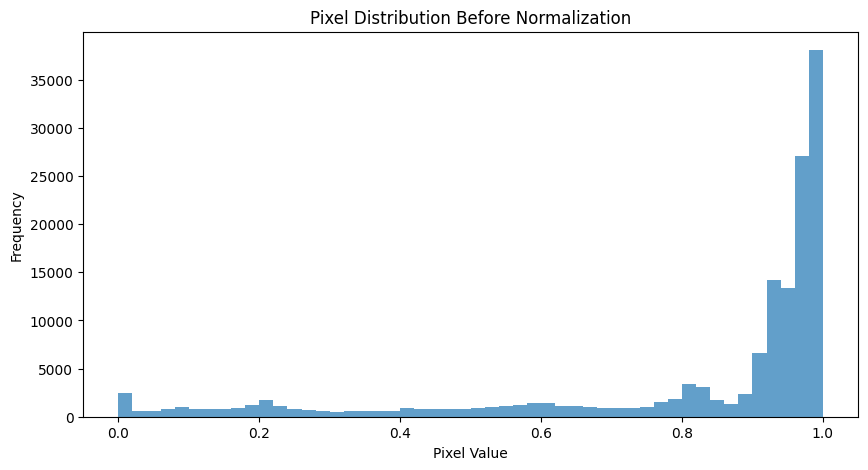

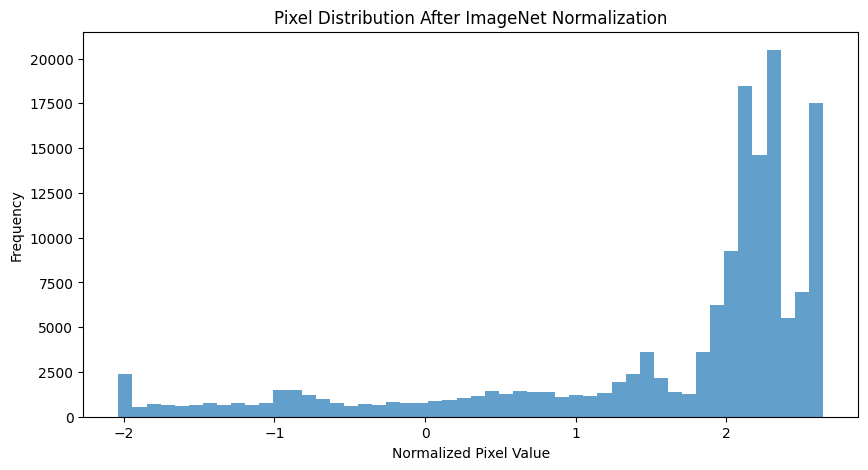

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

sample_path = stage4_files[0]

image = Image.open(sample_path).convert("RGB")

tensor_before = transforms.ToTensor()(image)
tensor_after = normalization_transform(image)

before_values = tensor_before.numpy().flatten()
after_values = tensor_after.numpy().flatten()

plt.figure(figsize=(10, 5))
plt.hist(before_values, bins=50, alpha=0.7)
plt.title("Pixel Distribution Before Normalization")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(after_values, bins=50, alpha=0.7)
plt.title("Pixel Distribution After ImageNet Normalization")
plt.xlabel("Normalized Pixel Value")
plt.ylabel("Frequency")
plt.show()

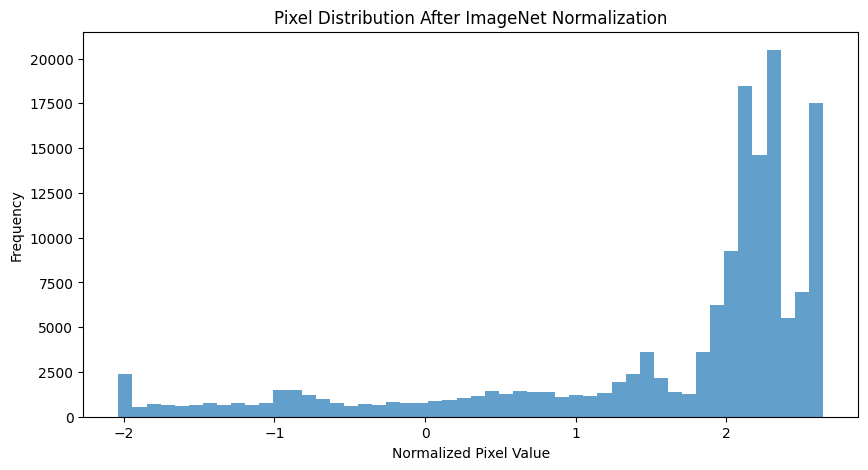

In [27]:
plt.figure(figsize=(10, 5))

plt.hist(
    after_values,
    bins=50,
    alpha=0.7
)

plt.title("Pixel Distribution After ImageNet Normalization")
plt.xlabel("Normalized Pixel Value")
plt.ylabel("Frequency")

plt.show()

In [28]:
from pathlib import Path

PROJECT = Path(
    "/content/drive/MyDrive/Waste_Classification_FINAL"
)

RAW_DIR = PROJECT / "data" / "raw"
PROCESSED_DIR = PROJECT / "data" / "processed"
RESULTS_DIR = PROJECT / "results"
REPORT_DIR = PROJECT / "audit_reports"
EDA_DIR = RESULTS_DIR / "eda_visualizations"
OUTPUT_DIR = RESULTS_DIR / "outputs"

for p in [
    PROCESSED_DIR,
    RESULTS_DIR,
    REPORT_DIR,
    EDA_DIR,
    OUTPUT_DIR
]:
    p.mkdir(parents=True, exist_ok=True)

IMAGE_EXTS = {
    ".jpg", ".jpeg", ".png",
    ".webp", ".bmp", ".gif",
    ".tif", ".tiff"
}

print("PROJECT =", PROJECT)
print("RAW_DIR =", RAW_DIR)

assert PROJECT.exists(), "Waste_Classification_FINAL was not found."
assert (PROJECT / "data").exists(), "data folder was not found."
assert (PROJECT / "data" / "processed").exists(), "processed folder was not found."

PROJECT = /content/drive/MyDrive/Waste_Classification_FINAL
RAW_DIR = /content/drive/MyDrive/Waste_Classification_FINAL/data/raw


In [29]:
STAGE4 = PROCESSED_DIR / "stage4_standardized"
assert STAGE4.exists(), "Stage 4 is missing."
files = sorted(STAGE4.rglob("*.jpg"))
print("Input images:", len(files))

Input images: 0


In [30]:
STAGE4 = PROCESSED_DIR / "stage4_standardized"

assert STAGE4.exists(), "Stage 4 is missing."

files = sorted(
    p for p in STAGE4.rglob("*")
    if p.is_file()
    and p.suffix.lower() in IMAGE_EXTS
)

print("Input images:", len(files))

assert len(files) == 2622, (
    f"Expected 2622 standardized images, "
    f"but found {len(files)}."
)

Input images: 2622


In [31]:
IMAGE_SIZE = (224,224)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

to_tensor = transforms.ToTensor()

normalize = transforms.Normalize(
    mean=IMAGENET_MEAN,
    std=IMAGENET_STD
)

In [32]:
from PIL import Image
import torch

# Select one standardized image
sample_path = files[0]

# Load standardized Stage 4 image
img = Image.open(sample_path).convert("RGB")

# Before normalization
tensor_before = to_tensor(img)

# After ImageNet normalization
tensor_after = normalize(tensor_before.clone())

print("Image:", sample_path.name)
print("PIL mode:", img.mode)
print("PIL size:", img.size)

print("\nBefore normalization:")
print("Shape:", tuple(tensor_before.shape))
print("Min:", tensor_before.min().item())
print("Max:", tensor_before.max().item())
print("Mean:", tensor_before.mean().item())

print("\nAfter ImageNet normalization:")
print("Shape:", tuple(tensor_after.shape))
print("Min:", tensor_after.min().item())
print("Max:", tensor_after.max().item())
print("Mean:", tensor_after.mean().item())

Image: 1-s2.0-S0892687521004477-ga1.png
PIL mode: RGB
PIL size: (224, 224)

Before normalization:
Shape: (3, 224, 224)
Min: 0.0
Max: 1.0
Mean: 0.9048386216163635

After ImageNet normalization:
Shape: (3, 224, 224)
Min: -2.1179039478302
Max: 2.640000104904175
Mean: 2.018231153488159


In [33]:
# ==========================================
# MEMBER 5 — FINAL NORMALIZATION VALIDATION
# ==========================================

print("=" * 60)
print("MEMBER 5 — PIXEL NORMALIZATION FINAL VALIDATION")
print("=" * 60)

# Dataset
print("\nDATASET")
print("-" * 60)
print("Input stage:", STAGE4)
print("Number of standardized images:", len(files))
print("Expected images:", 2622)

# Normalization configuration
print("\nNORMALIZATION CONFIGURATION")
print("-" * 60)
print("Method: ImageNet channel normalization")
print("Mean:", IMAGENET_MEAN)
print("Std :", IMAGENET_STD)

# Sample validation
print("\nSAMPLE VALIDATION")
print("-" * 60)
print("Sample:", sample_path.name)
print("Image mode:", img.mode)
print("Image size:", img.size)

print("\nBefore normalization")
print("Shape:", tuple(tensor_before.shape))
print("Min:", tensor_before.min().item())
print("Max:", tensor_before.max().item())

print("\nAfter normalization")
print("Shape:", tuple(tensor_after.shape))
print("Min:", tensor_after.min().item())
print("Max:", tensor_after.max().item())

# Assertions
assert len(files) == 2622
assert img.mode == "RGB"
assert img.size == (224, 224)
assert tuple(tensor_before.shape) == (3, 224, 224)
assert tuple(tensor_after.shape) == (3, 224, 224)

print("\n" + "=" * 60)
print("✓ 2,622 standardized images detected")
print("✓ RGB 224×224 input confirmed")
print("✓ ToTensor() conversion confirmed")
print("✓ ImageNet normalization confirmed")
print("✓ Tensor shape 3×224×224 confirmed")
print("✓ MEMBER 5 NORMALIZATION VALIDATION PASSED")
print("=" * 60)

MEMBER 5 — PIXEL NORMALIZATION FINAL VALIDATION

DATASET
------------------------------------------------------------
Input stage: /content/drive/MyDrive/Waste_Classification_FINAL/data/processed/stage4_standardized
Number of standardized images: 2622
Expected images: 2622

NORMALIZATION CONFIGURATION
------------------------------------------------------------
Method: ImageNet channel normalization
Mean: [0.485, 0.456, 0.406]
Std : [0.229, 0.224, 0.225]

SAMPLE VALIDATION
------------------------------------------------------------
Sample: 1-s2.0-S0892687521004477-ga1.png
Image mode: RGB
Image size: (224, 224)

Before normalization
Shape: (3, 224, 224)
Min: 0.0
Max: 1.0

After normalization
Shape: (3, 224, 224)
Min: -2.1179039478302
Max: 2.640000104904175

✓ 2,622 standardized images detected
✓ RGB 224×224 input confirmed
✓ ToTensor() conversion confirmed
✓ ImageNet normalization confirmed
✓ Tensor shape 3×224×224 confirmed
✓ MEMBER 5 NORMALIZATION VALIDATION PASSED


In [34]:
# ============================================================
# MEMBER 5 — FINAL OUTPUTS
# ============================================================

import json
import pandas as pd
from pathlib import Path

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
OUTPUT_DIR = (
    Path("/content/drive/MyDrive/Waste_Classification_FINAL")
    / "results"
    / "outputs"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 1. Create normalization specification
# ------------------------------------------------------------
normalization_spec = {
    "member": "Member 5",
    "student_id": "IT25102486",
    "contribution": "Pixel Normalization",
    "input_stage": "stage4_standardized",
    "input_image_count": len(files),
    "image_size": [224, 224],
    "input_mode": "RGB",
    "conversion": "torchvision.transforms.ToTensor()",
    "normalization": "ImageNet channel normalization",
    "mean": IMAGENET_MEAN,
    "std": IMAGENET_STD,
    "formula": "(x - mean) / std",
    "permanent_normalized_image_files": False,
    "implementation": "Runtime PyTorch tensor transform",
    "validation_status": "PASSED"
}

spec_path = OUTPUT_DIR / "member5_normalization_spec.json"

with open(spec_path, "w") as f:
    json.dump(normalization_spec, f, indent=4)

print("Created:", spec_path)

# ------------------------------------------------------------
# 2. Create Stage 5 manifest
# ------------------------------------------------------------
manifest_rows = []

for p in files:
    relative_path = p.relative_to(STAGE4).as_posix()

    manifest_rows.append({
        "relative_path": relative_path,
        "filename": p.name,
        "extension": p.suffix.lower(),
        "input_stage": "stage4_standardized",
        "normalization": "ImageNet",
        "mean_r": IMAGENET_MEAN[0],
        "mean_g": IMAGENET_MEAN[1],
        "mean_b": IMAGENET_MEAN[2],
        "std_r": IMAGENET_STD[0],
        "std_g": IMAGENET_STD[1],
        "std_b": IMAGENET_STD[2],
        "image_size": "224x224",
        "input_mode": "RGB",
        "status": "VALIDATED"
    })

member5_manifest = pd.DataFrame(manifest_rows)

manifest_path = OUTPUT_DIR / "member5_stage5_manifest.csv"

member5_manifest.to_csv(
    manifest_path,
    index=False
)

print("Created:", manifest_path)
print("Manifest rows:", len(member5_manifest))

# ------------------------------------------------------------
# 3. Final checks
# ------------------------------------------------------------
assert len(member5_manifest) == 2622
assert len(member5_manifest["relative_path"].unique()) == 2622

print("\n" + "=" * 60)
print("MEMBER 5 OUTPUT VALIDATION")
print("=" * 60)
print("✓ Normalization specification created")
print("✓ Stage 5 manifest created")
print("✓ Manifest rows:", len(member5_manifest))
print("✓ Unique image paths:", member5_manifest["relative_path"].nunique())
print("✓ ImageNet mean/std recorded")
print("✓ No permanent normalized image dataset created")
print("✓ MEMBER 5 OUTPUTS PASSED")
print("=" * 60)

Created: /content/drive/MyDrive/Waste_Classification_FINAL/results/outputs/member5_normalization_spec.json
Created: /content/drive/MyDrive/Waste_Classification_FINAL/results/outputs/member5_stage5_manifest.csv
Manifest rows: 2622

MEMBER 5 OUTPUT VALIDATION
✓ Normalization specification created
✓ Stage 5 manifest created
✓ Manifest rows: 2622
✓ Unique image paths: 2622
✓ ImageNet mean/std recorded
✓ No permanent normalized image dataset created
✓ MEMBER 5 OUTPUTS PASSED


In [1]:
# ============================================================
# MEMBER 5 - FINAL PROJECT CONFIGURATION
# ============================================================

from pathlib import Path

PROJECT = Path("/content/drive/MyDrive/Waste_Classification_FINAL")

DATA_DIR = PROJECT / "data"
PROCESSED_DIR = DATA_DIR / "processed"

# Member 4 input
STAGE4 = PROCESSED_DIR / "stage4_standardized"

RESULTS = PROJECT / "results"
OUTPUT_DIR = RESULTS / "outputs"
EDA_DIR = RESULTS / "eda_visualizations"

print("==========================================")
print("MEMBER 5 - PROJECT CONFIGURATION")
print("==========================================")
print("PROJECT :", PROJECT)
print("STAGE4  :", STAGE4)
print("==========================================")

assert PROJECT.exists(), f"❌ Project not found: {PROJECT}"
assert STAGE4.exists(), f"❌ Stage 4 not found: {STAGE4}"

print("✅ FINAL project confirmed")
print("✅ Stage 4 input confirmed")

MEMBER 5 - PROJECT CONFIGURATION
PROJECT : /content/drive/MyDrive/Waste_Classification_FINAL
STAGE4  : /content/drive/MyDrive/Waste_Classification_FINAL/data/processed/stage4_standardized


AssertionError: ❌ Project not found: /content/drive/MyDrive/Waste_Classification_FINAL

In [2]:
# ============================================================
# MEMBER 5 - GOOGLE DRIVE MOUNT CHECK
# ============================================================

from google.colab import drive
from pathlib import Path

drive.mount('/content/drive', force_remount=True)

PROJECT = Path("/content/drive/MyDrive/Waste_Classification_FINAL")

print("==========================================")
print("DRIVE / PROJECT CHECK")
print("==========================================")
print("Project:", PROJECT)
print("Exists :", PROJECT.exists())
print("==========================================")

assert PROJECT.exists(), (
    f"❌ FINAL project still not found: {PROJECT}"
)

print("✅ Google Drive mounted")
print("✅ Waste_Classification_FINAL found")

Mounted at /content/drive
DRIVE / PROJECT CHECK
Project: /content/drive/MyDrive/Waste_Classification_FINAL
Exists : True
✅ Google Drive mounted
✅ Waste_Classification_FINAL found


In [3]:
# ============================================================
# MEMBER 4 → MEMBER 5 HANDOFF VERIFICATION
# ============================================================

SUPPORTED_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".webp",
    ".gif", ".bmp", ".tif", ".tiff"
}

stage4_files = [
    p for p in STAGE4.rglob("*")
    if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS
]

print("==========================================")
print("MEMBER 4 → MEMBER 5 HANDOFF")
print("==========================================")
print(f"Stage 4 images found: {len(stage4_files)}")
print("Expected: 2622")
print("==========================================")

assert len(stage4_files) == 2622, (
    f"❌ Expected 2622 Stage 4 images, found {len(stage4_files)}"
)

print("✅ Member 4 → Member 5 handoff PASSED")

MEMBER 4 → MEMBER 5 HANDOFF
Stage 4 images found: 2622
Expected: 2622
✅ Member 4 → Member 5 handoff PASSED


In [4]:
# ============================================================
# MEMBER 5 - NORMALIZATION TRANSFORM VERIFICATION
# ============================================================

import torch
from torchvision import transforms
from PIL import Image

# ImageNet normalization parameters
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Correct normalization pipeline
normalization_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])

# Select one Stage 4 image
test_image_path = stage4_files[0]

print("==========================================")
print("MEMBER 5 - NORMALIZATION VERIFICATION")
print("==========================================")
print("Test image:", test_image_path.name)

# Load image
with Image.open(test_image_path) as img:
    img = img.convert("RGB")

print("Original mode:", img.mode)
print("Original size:", img.size)

# Apply normalization
tensor = normalization_transform(img)

print("==========================================")
print("TRANSFORM RESULT")
print("==========================================")
print("Tensor shape:", tuple(tensor.shape))
print("Tensor dtype:", tensor.dtype)
print("Tensor min:", tensor.min().item())
print("Tensor max:", tensor.max().item())
print("Tensor mean:", tensor.mean().item())
print("==========================================")

# ------------------------------------------------------------
# Assertions
# ------------------------------------------------------------

assert img.mode == "RGB", (
    f"❌ Expected RGB image, found {img.mode}"
)

assert tensor.shape == (3, 224, 224), (
    f"❌ Expected tensor shape (3,224,224), "
    f"found {tuple(tensor.shape)}"
)

assert tensor.dtype == torch.float32, (
    f"❌ Expected float32 tensor, found {tensor.dtype}"
)

# Check normalization parameters
assert IMAGENET_MEAN == [0.485, 0.456, 0.406]
assert IMAGENET_STD == [0.229, 0.224, 0.225]

print("✅ Input image is RGB")
print("✅ Output tensor shape = 3 × 224 × 224")
print("✅ Tensor dtype = float32")
print("✅ ImageNet mean/std are correct")
print("✅ Normalization transform is working correctly")

MEMBER 5 - NORMALIZATION VERIFICATION
Test image: -can-massa-italy-august-condensed-white-background-company-american-76189952.png
Original mode: RGB
Original size: (224, 224)
TRANSFORM RESULT
Tensor shape: (3, 224, 224)
Tensor dtype: torch.float32
Tensor min: -2.0357141494750977
Tensor max: 2.640000104904175
Tensor mean: 1.6031099557876587
✅ Input image is RGB
✅ Output tensor shape = 3 × 224 × 224
✅ Tensor dtype = float32
✅ ImageNet mean/std are correct
✅ Normalization transform is working correctly


In [7]:
# ============================================================
# MEMBER 5 - FINAL NORMALIZATION OUTPUT CHECK
# ============================================================

print("==========================================")
print("MEMBER 5 - FINAL OUTPUT CHECK")
print("==========================================")

# Normalization must be performed as a runtime transform.
# There should NOT be a permanent Stage 5 image directory.

STAGE5 = PROCESSED_DIR / "stage5_normalized"

print("Stage 4:", STAGE4)
print("Stage 5:", STAGE5)

if STAGE5.exists():
    stage5_images = [
        p for p in STAGE5.rglob("*")
        if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS
    ]

    print(f"Stage 5 image files found: {len(stage5_images)}")

    assert len(stage5_images) == 0, (
        "❌ A permanent normalized image dataset was found. "
        "Normalization should be performed as a tensor transform."
    )

    print("✅ Stage 5 contains no permanent image dataset")
else:
    print("✅ No permanent Stage 5 normalized image folder exists")

print("==========================================")
print("✅ Normalization is correctly implemented as a runtime transform")
print("✅ Member 5 is ready for Member 6")

MEMBER 5 - FINAL OUTPUT CHECK
Stage 4: /content/drive/MyDrive/Waste_Classification_FINAL/data/processed/stage4_standardized
Stage 5: /content/drive/MyDrive/Waste_Classification_FINAL/data/processed/stage5_normalized
✅ No permanent Stage 5 normalized image folder exists
✅ Normalization is correctly implemented as a runtime transform
✅ Member 5 is ready for Member 6
